<a href="https://colab.research.google.com/github/vnevzorovaa/pyad-2024/blob/lab-1/_py_1_pyspark_basics_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Данные

Об авиаперевозках с 1987 года: https://www.transtats.bts.gov/Tables.asp?QO_VQ=EFD&QO_anzr=Nv4yv0r%FDb0-gvzr%FDcr4s14zn0pr%FDQn6n&QO_fu146_anzr=b0-gvzr

Ниже скачиваются только данные за часть 2023 и 2024 годов.

In [32]:
!gdown 1NQuold7jvGZfHikbvtj0QynbhM90pT8L
!gdown 1HNAGhPHE6BmamcI0D767-BFhF4BWs6Hh
!gdown 1ERgltJRuybLl7sIUUVckzpUVzyP1ttCq
!gdown 1XrUk6ZYwQLQTjtsMHKxzzERP4dCLMEao
!gdown 1qy95Qpd93VClYPethMtMDJdAMBl21fnW
!gdown 1js5pbc_xe6kP7W4_lp6HaeXR0oAw2ZDL
!gdown 1qb4_uKGy0KU_4jRzaauqeObaaCQMtdBZ
!gdown 1TuC71TgrJDgpOvQVKl9jn89fAr9El1Pa
!gdown 1nt7e9Pszf2-IB3GsKHNRHZ_SPzxS0E2L
!gdown 1V5tCiD9jRCss0KoJxk-r1zOCw3onwez3
!gdown 1WsKGiVBV2p-sgiDePT6HZKUezWPc2zUH

Downloading...
From: https://drive.google.com/uc?id=1NQuold7jvGZfHikbvtj0QynbhM90pT8L
To: /content/T_ONTIME_REPORTING.csv
100% 67.6M/67.6M [00:00<00:00, 81.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HNAGhPHE6BmamcI0D767-BFhF4BWs6Hh
To: /content/T_ONTIME_REPORTING 2.csv
100% 66.4M/66.4M [00:00<00:00, 167MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ERgltJRuybLl7sIUUVckzpUVzyP1ttCq
To: /content/T_ONTIME_REPORTING 3.csv
100% 61.6M/61.6M [00:00<00:00, 79.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XrUk6ZYwQLQTjtsMHKxzzERP4dCLMEao
To: /content/T_ONTIME_REPORTING 4.csv
100% 71.8M/71.8M [00:00<00:00, 156MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qy95Qpd93VClYPethMtMDJdAMBl21fnW
To: /content/T_ONTIME_REPORTING 5.csv
100% 69.3M/69.3M [00:00<00:00, 153MB/s]
Downloading...
From: https://drive.google.com/uc?id=1js5pbc_xe6kP7W4_lp6HaeXR0oAw2ZDL
To: /content/T_ONTIME_REPORTING 6.csv
100% 71.1M/71.1M [00:00<00:00, 110MB/s]
Downloading...
F

#### Основные функции PySpark

В отдельном колабе: https://colab.research.google.com/drive/1noKypPI5ymbofp0YPtRH9gYSqNPAiTAT?usp=sharing

### Пример работы с PySpark
Для работы с PySpark мы можем использовать SparkSession для создания сессии и работы с большими данными.

In [33]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.5.3/spark-3.5.3-bin-hadoop3.5.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.5.3/spark-3.5.3-bin-hadoop3.5.tgz
!tar xf spark-3.5.3-bin-hadoop3.5.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys


import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession \
       .builder \
       .appName("Our First Spark Example") \
       .getOrCreate()

spark

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,637 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,660 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [3,799 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,231 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jamm

In [34]:
df = spark.read.csv('/content/T_ONTIME_REPORTING.csv', header=True, inferSchema=True)
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 2.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 3.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 4.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 5.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 6.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 7.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 8.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 9.csv', header=True, inferSchema=True))
df = df.union(spark.read.csv('/content/T_ONTIME_REPORTING 10.csv', header=True, inferSchema=True))

df.show()

+----+--------------------+-----------------+-----------------+------+--------------------+---------------+----+--------------------+---------+---------+---------+-------------------+--------+-------------+-------------+---------+--------------+-------------------+
|YEAR|             FL_DATE|OP_UNIQUE_CARRIER|ORIGIN_AIRPORT_ID|ORIGIN|    ORIGIN_CITY_NAME|DEST_AIRPORT_ID|DEST|      DEST_CITY_NAME|DEP_DELAY|ARR_DELAY|CANCELLED|ACTUAL_ELAPSED_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|
+----+--------------------+-----------------+-----------------+------+--------------------+---------------+----+--------------------+---------+---------+---------+-------------------+--------+-------------+-------------+---------+--------------+-------------------+
|2024|1/1/2024 12:00:00 AM|               9E|            10135|   ABE|Allentown/Bethleh...|          10397| ATL|         Atlanta, GA|     -2.0|    -35.0|      0.0|              119.0|   692.0|         N

## Задание 1

1. Сколько различных перевозчиков представлено в датасете?
2. Какие 5 перевозчиков сделали наибольшее число перелетов?

Могут понадобиться методы:
- dropDuplicates()
- select()
- groupBy()
- orderBy()
- limit()
- count()

In [35]:
distinct_carriers = df.select("OP_UNIQUE_CARRIER").dropDuplicates().count()
print(f"Количество различных перевозчиков: {distinct_carriers}")

Количество различных перевозчиков: 15


In [36]:
top_5_carriers = (
    df.groupBy("OP_UNIQUE_CARRIER")
    .count()
    .orderBy("count", ascending=False)
    .limit(5)
)

In [37]:
top_5_carriers.show()

+-----------------+-------+
|OP_UNIQUE_CARRIER|  count|
+-----------------+-------+
|               WN|1179623|
|               DL| 811280|
|               AA| 784153|
|               UA| 602736|
|               OO| 556873|
+-----------------+-------+



## Задание 2

Найдите 10 самых частых направлений, если:
- Направление – это пара «аэропорт вылета-аэропорт прилета»
- Направление – это пара «город вылета-город прилета»
- Направление – это город прилета.


Могут понадобиться методы:
- groupBy()
- orderBy()
- limit()
- count()

In [38]:
airport_direction = (
    df.withColumn("DIRECTION", F.concat_ws("-", "ORIGIN", "DEST"))
    .groupBy("DIRECTION")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
)

airport_direction.show()

+---------+-----+
|DIRECTION|count|
+---------+-----+
|  OGG-HNL|10504|
|  HNL-OGG|10487|
|  SFO-LAX| 9631|
|  LAX-SFO| 9631|
|  LAX-LAS| 8739|
|  LAS-LAX| 8715|
|  ORD-LGA| 8432|
|  LGA-ORD| 8432|
|  DCA-BOS| 8306|
|  BOS-DCA| 8305|
+---------+-----+



In [39]:
city_direction = (
    df.withColumn("DIRECTION", F.concat_ws("-", "ORIGIN_CITY_NAME", "DEST_CITY_NAME"))
    .groupBy("DIRECTION")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
)

city_direction.show()

+--------------------+-----+
|           DIRECTION|count|
+--------------------+-----+
|Chicago, IL-New Y...|12856|
|New York, NY-Chic...|12855|
|Boston, MA-New Yo...|12337|
|New York, NY-Bost...|12318|
|Kahului, HI-Honol...|10504|
|Honolulu, HI-Kahu...|10487|
|Miami, FL-New Yor...| 9711|
|New York, NY-Miam...| 9709|
|San Francisco, CA...| 9631|
|Los Angeles, CA-S...| 9631|
+--------------------+-----+



In [40]:
destination_city = (
    df.groupBy("DEST_CITY_NAME")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
)

destination_city.show()

+--------------------+------+
|      DEST_CITY_NAME| count|
+--------------------+------+
|         Chicago, IL|282723|
|         Atlanta, GA|277089|
|        New York, NY|247223|
|          Denver, CO|237001|
|Dallas/Fort Worth...|234809|
|       Charlotte, NC|161726|
|     Los Angeles, CA|160652|
|      Washington, DC|157883|
|       Las Vegas, NV|156322|
|         Phoenix, AZ|150906|
+--------------------+------+



## Задание 3

1. Узнайте, сколько было отмен рейсов в каждом месяце. Отсортируйте ответ по числу отмен.
2. Для каждого месяца определите причину задержки, из-за которой было отложено больше всего рейсов.

Могут понадобиться методы/функции:
- withColumn()
- split()
- getItem()
- cast()
- groupBy()
- orderBy()
- sum()
- isNotNull()
- col()
- when()
- otherwise()
- agg()
- greatest()

In [41]:
df_with_month = df.withColumn("MONTH", F.split(F.col("FL_DATE"), "/").getItem(0).cast("int"))

cancelled_per_month = (
    df_with_month.filter(F.col("CANCELLED") == 1)
    .groupBy("MONTH")
    .agg(F.count("*").alias("Cancelled_Count"))
    .orderBy(F.desc("Cancelled_Count"))
)

print("Количество отменённых рейсов по месяцам:")
cancelled_per_month.show()

Количество отменённых рейсов по месяцам:
+-----+---------------+
|MONTH|Cancelled_Count|
+-----+---------------+
|    1|          30684|
|    7|          14606|
|    6|          12219|
|    4|           9589|
|    8|           9172|
|    2|           9019|
|    3|           7406|
|    5|           3310|
|   11|            819|
+-----+---------------+



In [42]:
delay_reasons = ["CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]

# Суммируем все типы задержек и находим максимальную причину
most_delays_by_month = (
    df_with_month.groupBy("MONTH")  # Группируем по месяцу
    .agg(
        *[F.sum(reason).alias(reason) for reason in delay_reasons],  # Считаем сумму для каждой причины
        F.greatest(*[F.sum(reason) for reason in delay_reasons]).alias("MAX_DELAY")  # Находим максимальную сумму
    )
)

# Добавляем столбец с названием причины задержки
most_delays_by_month = most_delays_by_month.withColumn(
    "TOP_REASON",
    F.when(F.col("CARRIER_DELAY") == F.col("MAX_DELAY"), "CARRIER_DELAY")
     .when(F.col("WEATHER_DELAY") == F.col("MAX_DELAY"), "WEATHER_DELAY")
     .when(F.col("NAS_DELAY") == F.col("MAX_DELAY"), "NAS_DELAY")
     .when(F.col("SECURITY_DELAY") == F.col("MAX_DELAY"), "SECURITY_DELAY")
     .when(F.col("LATE_AIRCRAFT_DELAY") == F.col("MAX_DELAY"), "LATE_AIRCRAFT_DELAY")
)

print("Причина задержки с наибольшим числом рейсов в каждом месяце:")
most_delays_by_month.select("MONTH", "TOP_REASON", "MAX_DELAY").orderBy("MONTH").show()

Причина задержки с наибольшим числом рейсов в каждом месяце:
+-----+-------------------+---------+
|MONTH|         TOP_REASON|MAX_DELAY|
+-----+-------------------+---------+
|    1|LATE_AIRCRAFT_DELAY|6721612.0|
|    2|      CARRIER_DELAY|2392270.0|
|    3|LATE_AIRCRAFT_DELAY|3465431.0|
|    4|LATE_AIRCRAFT_DELAY|3478309.0|
|    5|LATE_AIRCRAFT_DELAY|2748081.0|
|    6|LATE_AIRCRAFT_DELAY|4752557.0|
|    7|LATE_AIRCRAFT_DELAY|5600405.0|
|    8|LATE_AIRCRAFT_DELAY|3968456.0|
|   11|      CARRIER_DELAY|1924411.0|
+-----+-------------------+---------+



## Задание 4

Создайте и обучите модель логистической регрессии для предсказания отмены рейса.

Закодируйте категориальные признаки в one-hot формат: разбейте столбец из $n$ категорий на $n$ столбцов, где в каждой строке $1$ будет стоять в том столбце, название которого раньше было категорией, к которой относится этот объект.

Сначала закодируем таким образом столбец с перевозчиком (`OP_UNIQUE_CARRIER`).

In [43]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

carr_indexer = StringIndexer(inputCol="OP_UNIQUE_CARRIER", outputCol="carrier_index")
carr_encoder = OneHotEncoder(inputCol="carrier_index", outputCol="carrier_fact")

Столбцы `ORIGIN` (пункт вылета) и `DEST` (пункт прилета) закодируйте аналогично самостоятельно.

In [44]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F

In [45]:
origin_indexer = StringIndexer(inputCol="ORIGIN", outputCol="origin_index")
origin_encoder = OneHotEncoder(inputCol="origin_index", outputCol="origin_fact")

dest_indexer = StringIndexer(inputCol="DEST", outputCol="dest_index")
dest_encoder = OneHotEncoder(inputCol="dest_index", outputCol="dest_fact")

Выделите целевую переменную. Ее важно назвать `label`. По этому названию дальше метод `fit()` отличит ее от других столбцов. Целевая переменная должна получиться из значений столбца `CANCELLED` (отмена рейса).

In [46]:
from pyspark.sql.functions import split, when, col, greatest

In [47]:
df3 = df
df3 = df3.withColumn("label", col("CANCELLED"))

Соберите все признаки, которые будут использоваться для обучения, в один вектор `features`. В столбце `DATE` должен лежать месяц, в который был совершен рейс.

In [48]:
df3 = df3.withColumn("DATE", split(col("FL_DATE"), "/").getItem(0).cast("int"))


In [49]:
from pyspark.ml.feature import VectorAssembler

vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "carrier_fact", "dest_fact", "origin_fact"], outputCol="features")

Объедините все предобработки в один пайплайн. Он будет состоять из кодирования категориальных переменных и объединения новых столбцов с некоторыми старыми в матрицу признаков.

In [50]:
from pyspark.ml import Pipeline

flights_pipe = Pipeline(stages=[dest_indexer, dest_encoder, carr_indexer, carr_encoder, origin_indexer, origin_encoder, vec_assembler])

Выполните созданный пайплайн.

In [51]:
piped_data = flights_pipe.fit(df3).transform(df3)

Разделите датасет на тренировочную и тестовую выборки.

In [52]:
training, test = piped_data.randomSplit([.7, .3])

Создайте модель – логистическую регрессию.

In [53]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression()

Введите метрику оценки качества предсказания – ROC-AUC. Метрика рассчитывается на основе матрицы неточностей. Чем ближе она к 1, тем качественнее классификатор. Значение 0.5 означает, что предсказания случайны.

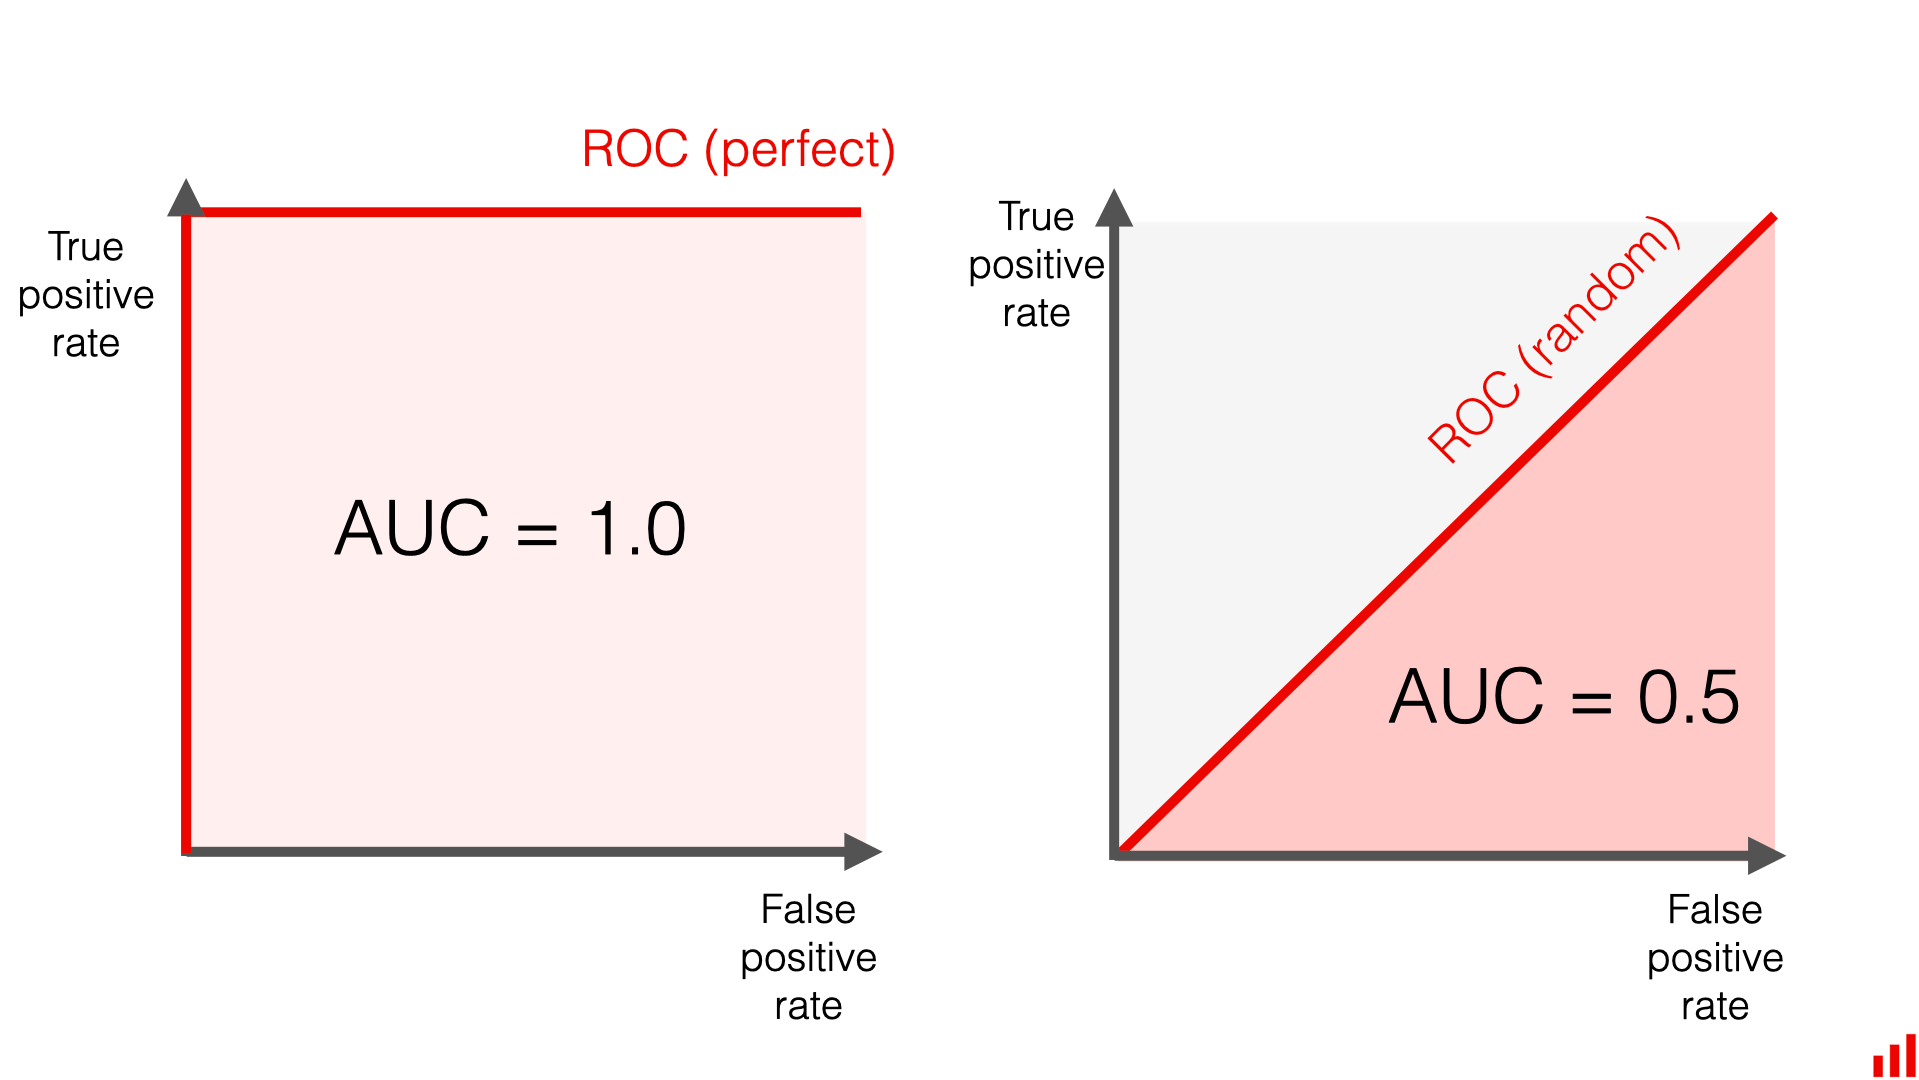

In [54]:
import pyspark.ml.evaluation as evals

evaluator = evals.BinaryClassificationEvaluator(metricName="areaUnderROC")

Обучите модель.

In [55]:
model = lr.fit(training)
print(model)

LogisticRegressionModel: uid=LogisticRegression_16af74688130, numClasses=2, numFeatures=712


Протестируйте модель.

In [56]:
test_results = model.transform(test)
print(evaluator.evaluate(test_results))

0.6699249670908111


Точность классификатора – чуть меньше 0.7. Результат посредственный. Проведите несколько экспериментов с предобработкой и ответьте на следующие вопросы:
1. Повысится ли качество, если не использовать данные о пункте вылета?
2. Повысится ли качество, если не использовать данные о пункте прилета?
3. Повысится ли качество, если не использовать данные о перевозчике?
4. Повысится ли качество, если не использовать данные о месяце перелета?
5. Повысится ли качество, если задать направление полета иначе (см. задание 2)?

In [57]:
vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "carrier_fact", "dest_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_indexer, dest_encoder, carr_indexer, carr_encoder, origin_indexer, origin_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Без данных о пункте вылета:", evaluator.evaluate(test_results))

Без данных о пункте вылета: 0.6471575705841165


In [58]:
vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "carrier_fact", "origin_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_indexer, dest_encoder, carr_indexer, carr_encoder, origin_indexer, origin_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Без данных о пункте прилета:", evaluator.evaluate(test_results))

Без данных о пункте прилета: 0.6478615299060747


In [59]:
vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "dest_fact", "origin_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_indexer, dest_encoder, carr_indexer, carr_encoder, origin_indexer, origin_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Без данных о перевозчике:", evaluator.evaluate(test_results))

Без данных о перевозчике: 0.6592053512495749


In [60]:
vec_assembler = VectorAssembler(inputCols=["carrier_fact", "DISTANCE", "dest_fact", "origin_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_indexer, dest_encoder, carr_indexer, carr_encoder, origin_indexer, origin_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Без данных о месяце перелета:", evaluator.evaluate(test_results))

Без данных о месяце перелета: 0.6402032293786399


In [61]:
dest_city_indexer = StringIndexer(inputCol="DEST_CITY_NAME", outputCol="dest_city_index")
dest_city_encoder = OneHotEncoder(inputCol="dest_city_index", outputCol="dest_city_fact")

origin_city_indexer = StringIndexer(inputCol="ORIGIN_CITY_NAME", outputCol="origin_city_index")
origin_city_encoder = OneHotEncoder(inputCol="origin_city_index", outputCol="origin_city_fact")

vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "carrier_fact", "origin_city_fact", "dest_city_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_city_indexer, dest_city_encoder, carr_indexer, carr_encoder, origin_city_indexer, origin_city_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Если задать направление полета как пара городов:", evaluator.evaluate(test_results))

Если задать направление полета как пара городов: 0.6655142647673826


In [62]:
vec_assembler = VectorAssembler(inputCols=["DATE", "DISTANCE", "carrier_fact", "dest_city_fact"], outputCol="features")
flights_pipe = Pipeline(stages=[dest_city_indexer, dest_city_encoder, carr_indexer, carr_encoder, vec_assembler])
piped_data = flights_pipe.fit(df3).transform(df3)
training, test = piped_data.randomSplit([.7, .3])
model = lr.fit(training)
test_results = model.transform(test)
print("Если задать направление полета как город прилета:", evaluator.evaluate(test_results))

Если задать направление полета как город прилета: 0.6476002785426002


## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе тестов нет.
- Загружайте в формате .ipynb, а не ссылкой на колаб.
- Пул-реквест нужно сделать в ветку `lab1`.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**